# k-Nearest Neighbors Classification on MNIST and Fashion-MNIST

## Project Overview

This notebook develops k-nearest-neighbor classification from simple baselines to a fully vectorized implementation, confidence analysis, prototype compression, and scikit-learn performance studies on MNIST and Fashion-MNIST.

### Technical Coverage

- Raw image and pixel inspection
- Simple classification baselines
- One-neighbor classification from scratch
- Vectorized Euclidean-distance computation
- Custom confusion matrix
- k-NN implementation from scratch
- MNIST and Fashion-MNIST comparison
- Class-mean prototypes
- Vote-based confidence analysis
- Uniform vs. distance-weighted k-NN
- Manhattan vs. Euclidean distance
- Constant-feature removal
- Brute-force, KD-tree, and Ball-tree neighbor search
- Runtime and accuracy comparison

## 1. Environment

In [1]:
import tensorflow as tf
import numpy as np
from scipy import stats
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier


## 2. Problem Definition

Each MNIST observation is a 28×28 grayscale image represented by 784 pixel-intensity values, with an integer target indicating the digit class.

**Input:** image feature vectors \(X\) containing 784 pixel values and class labels \(y\).

**Output:** a prediction model that assigns a digit class to previously unseen image vectors.

Model quality is measured by comparing predicted classes with the known test labels.

## 3. MNIST Data Inspection

The MNIST dataset contains 28×28 grayscale digit images. The following cells inspect the array dimensions, visualize a random image, and display its raw pixel intensities before normalization.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


Class: 8


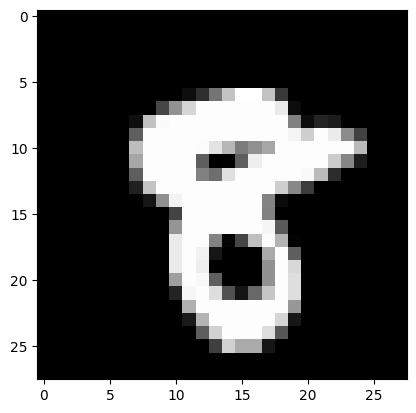

000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 014 047 116 195 254 255 195 056 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 070 146 213 253 253 253 253 253 253 234 012 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 014 194 251 253 253 253 253 253 253 253 253 253 129 012 037 027 000 

In [9]:
im = np.random.randint(0,x_train.shape[0])
plt.imshow(x_train[im],cmap='gray')
print('Class:',y_train[im])
plt.show()

for i in range(28):
    for j in range(28):
        print(f'{x_train[im,i,j]:03}',end=' ')
    print()

In [6]:
x_train[im,5,10]


np.uint8(0)

In [7]:
x_train[im,5,11]

np.uint8(0)

In [8]:
x_train.shape[0]

60000

### Flattening and Normalization

Each 28×28 image is converted into a 784-element vector and scaled to the [0, 1] range.

In [10]:
x_train = x_train.reshape(x_train.shape[0],-1)/255
x_test = x_test.reshape(x_test.shape[0],-1)/255

## 4. Simple Baselines Before k-NN

Three progressively stronger instance-prediction baselines provide context for the k-NN results: a constant-zero predictor, a majority-class predictor, and a direct one-nearest-neighbor implementation.

In [11]:
def accuracy(y,pred):
  # Assumes y[i] is the actual class of instance i and pred[i] is the predicted class of instance i
  # Returns the fraction of predictions that are correct (prediction for instance i is correct if y[i]==pred[i])
  return np.mean(pred==y)

### Constant-Zero Predictor

In [12]:
class model1:

    def __init__(self):
        self.parameters = np.zeros((x_train.shape[1], 1))

    def fit(self, x_train, y_train):
        pass

    def predict(self, x_test):
        return np.dot(x_test, self.parameters[:x_test.shape[0]])

model = model1()
model.fit(x_train, y_train)
pred = model.predict(x_test)
print('Accuracy = {:6.3f}'.format(accuracy(y_test, pred)))
print('Results for first 30 test examples')
print('Actual class:', y_test[:30])
print('Predictions:', pred[:30])

Accuracy =  0.098
Results for first 30 test examples
Actual class: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4 9 6 6 5 4 0 7 4 0 1]
Predictions: [[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]


### Majority-Class Predictor

In [13]:
class model2:

    def __init__(self):
        self.parameters = np.zeros((x_train.shape[1], 1))

    def fit(self, x_train, y_train):
        self.common = np.argmax([np.sum(y_train == i) for i in set(y_train)])

    def predict(self, x_test):
        return np.dot(x_test, self.parameters[:x_test.shape[0]]) + self.common

model = model2()
model.fit(x_train, y_train)
pred = model.predict(x_test)
print('Accuracy = {:6.3f}'.format(accuracy(y_test, pred)))
print('Results for first 30 test examples')
print('Actual class:', y_test[:30])
print('Predictions:', pred[:30])

Accuracy =  0.114
Results for first 30 test examples
Actual class: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4 9 6 6 5 4 0 7 4 0 1]
Predictions: [[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]


### One-Nearest-Neighbor from Scratch

In [14]:
class model3:

    def __init__(self):
        self.x_train = x_train
        self.y_train = y_train

    def fit(self, x_train, y_train):
        pass

    def predict(self, x_test):
        return [
            self.y_train[
                np.argmin(np.sum((x_train - x_test[i])**2, axis=1))
            ]
            for i in range(0, 30)
        ]

model = model3()
model.fit(x_train, y_train)
pred = model.predict(x_test)
print('Accuracy = {:6.3f}'.format(accuracy(y_test[:30], pred)))
print('Results for first 30 test examples')
print('Actual class:', y_test[:30])
print('Predictions:', pred[:30])

Accuracy =  1.000
Results for first 30 test examples
Actual class: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4 9 6 6 5 4 0 7 4 0 1]
Predictions: [np.uint8(7), np.uint8(2), np.uint8(1), np.uint8(0), np.uint8(4), np.uint8(1), np.uint8(4), np.uint8(9), np.uint8(5), np.uint8(9), np.uint8(0), np.uint8(6), np.uint8(9), np.uint8(0), np.uint8(1), np.uint8(5), np.uint8(9), np.uint8(7), np.uint8(3), np.uint8(4), np.uint8(9), np.uint8(6), np.uint8(6), np.uint8(5), np.uint8(4), np.uint8(0), np.uint8(7), np.uint8(4), np.uint8(0), np.uint8(1)]


## 5. Vectorized k-NN from Scratch

The next implementation computes the complete Euclidean distance matrix using matrix operations, identifies the nearest neighbors, and predicts the most common class. A custom confusion-matrix function is also retained.

In [15]:
def conf_mat(y_true,y_pred):
  n_classes = np.amax(y_true)+1
  cm = np.zeros((n_classes,n_classes), dtype=int)
  for i in range(y_true.shape[0]):
    cm[y_true[i],y_pred[i]] +=1
  return cm

In [17]:
def distance(x_test,x_train):
    # Returns 2D array dist
    # where dist[i,j] is the Euclidean distance from training example i to test example j
    dist = np.sum(x_train**2,axis=1).reshape(-1,1) # dist = x_train**2
    dist = dist - 2*np.matmul(x_train,x_test.T)    # dist = X_train**2  - 2*X_train*X_test
    dist = dist + np.sum(x_test.T**2,axis=0).reshape(1,-1) # dist = X_train**2  - 2*X_train*X_test + X_test**2 - Not really necessary
    dist = np.sqrt(dist)
    return  dist

def accuracy(p,y):
    return np.mean(p==y)

def most_common(labels):
    # stats.mode returns ModeResult(mode, count)
    # mode[0] is an array of shape (1, num_test_samples), so we flatten it.
    return stats.mode(labels,axis=0)[0].flatten()

def knn(x_train, y_train, x_test, k):
    d = distance(x_test,x_train)
    neighbors = np.argsort(d,axis=0)[:k]
    pred = most_common(y_train[neighbors])
    return pred

pred = knn(x_train, y_train, x_test, 3)
print('Accuracy = {:.4f}'.format(accuracy(pred,y_test)))
print('Confusion Matrix')
print(conf_mat(y_test,pred))

Accuracy = 0.9705
Confusion Matrix
[[ 974    1    1    0    0    1    2    1    0    0]
 [   0 1133    2    0    0    0    0    0    0    0]
 [  10    9  996    2    0    0    0   13    2    0]
 [   0    2    4  976    1   13    1    7    3    3]
 [   1    6    0    0  950    0    4    2    0   19]
 [   6    1    0   11    2  859    5    1    3    4]
 [   5    3    0    0    3    3  944    0    0    0]
 [   0   21    5    0    1    0    0  991    0   10]
 [   8    2    4   16    8   11    3    4  914    4]
 [   4    5    2    8    9    2    1    8    2  968]]


> **Computation note:** constructing the full train-by-test distance matrix is intentionally direct and can require substantial memory on the full MNIST dataset. The saved result is retained because it demonstrates the underlying k-NN calculation explicitly.

## 6. Fashion-MNIST Classification

The same from-scratch three-neighbor implementation is applied to Fashion-MNIST, providing a second 10-class image dataset with a more difficult visual classification problem.

In [18]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train = np.float32(x_train/255).reshape(x_train.shape[0],-1)
x_test = np.float32(x_test/255).reshape(x_test.shape[0],-1)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Class: 3


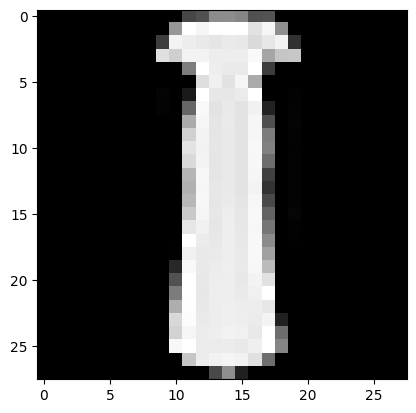

Class: 7


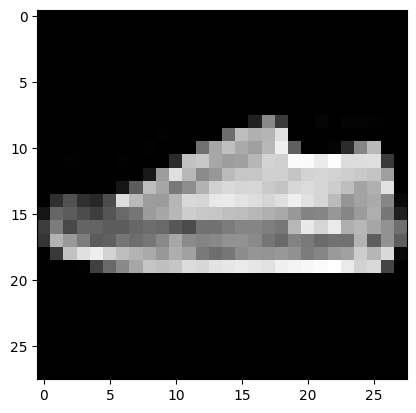

Class: 7


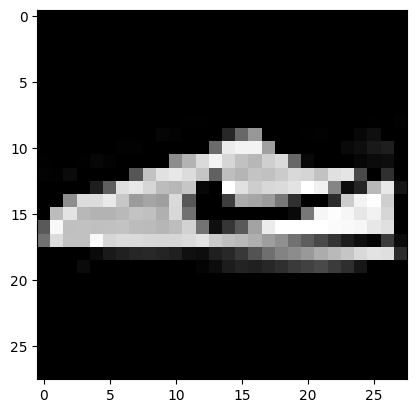

Class: 5


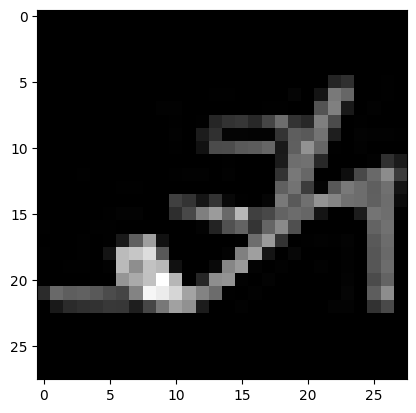

Class: 6


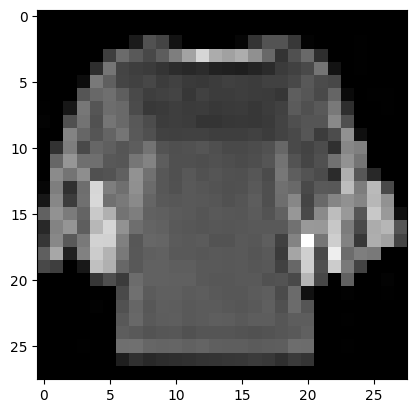

In [19]:
for i in range(5):
  im = np.random.randint(0,x_train.shape[0])
  plt.imshow(x_train[im].reshape(28,28),cmap='gray')
  print('Class:',y_train[im])
  plt.show()

In [20]:
start = time.time()
pred = knn(x_train, y_train, x_test, 3)
elapsed_time = time.time() - start
print('Accuracy = {:.4f}'.format(accuracy_score(pred,y_test)))
print('Elapsed time = {:.4f} secs'.format(elapsed_time))
print('Confusion Matrix')
print(conf_mat(y_test,pred))

Accuracy = 0.8541
Elapsed time = 38.6246 secs
Confusion Matrix
[[853   1  16  15   3   0 106   1   5   0]
 [  9 971   2  11   4   0   2   0   1   0]
 [ 27   2 812   8  78   0  73   0   0   0]
 [ 48   7  22 855  30   0  36   0   2   0]
 [  5   3 141  24 743   0  82   0   2   0]
 [  1   0   0   1   0 835   3  90   0  70]
 [177   3 132  21  63   0 595   0   9   0]
 [  0   0   0   0   0   3   0 952   0  45]
 [  7   1  10   3   3   1  16   6 952   1]
 [  0   0   0   0   0   2   0  24   1 973]]


## 7. Prototype Compression with Class Means

Instead of retaining every training image, each class is represented by its mean image. One-nearest-neighbor classification is then performed using only ten prototype images. This greatly reduces prediction time at the cost of accuracy.

In [21]:
def find_means(x_train, y_train):
  means = np.zeros((10,x_train.shape[1]))
  for i in range(10):
    means[i] = np.mean(x_train[y_train==i],axis=0)
  return means

### MNIST Class-Mean Prototypes

In [22]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = np.float32(x_train/255).reshape(x_train.shape[0],-1)
x_test = np.float32(x_test/255).reshape(x_test.shape[0],-1)

In [23]:
x_train_means = find_means(x_train, y_train)

Class: 0


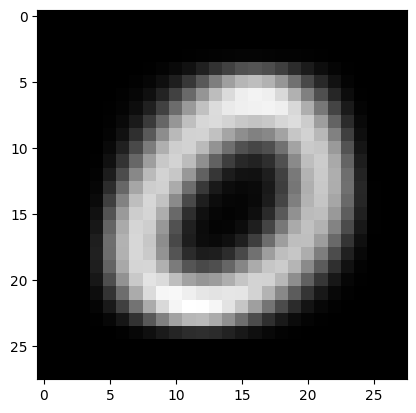

Class: 1


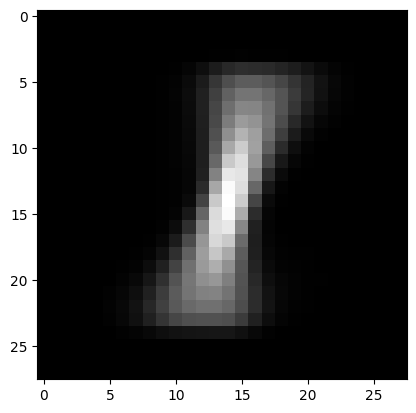

Class: 2


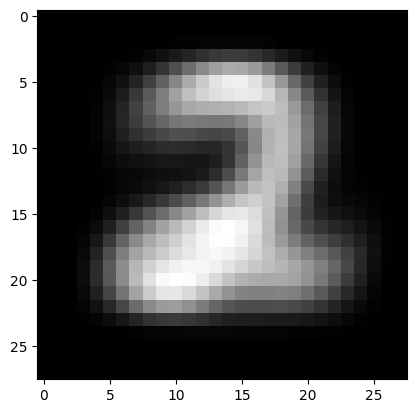

Class: 3


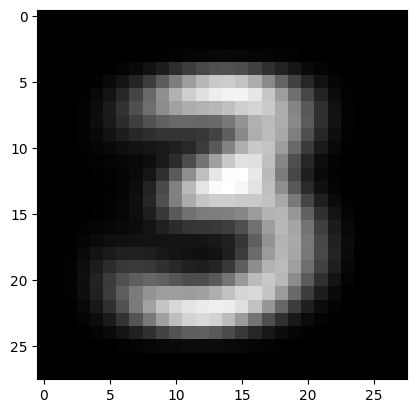

Class: 4


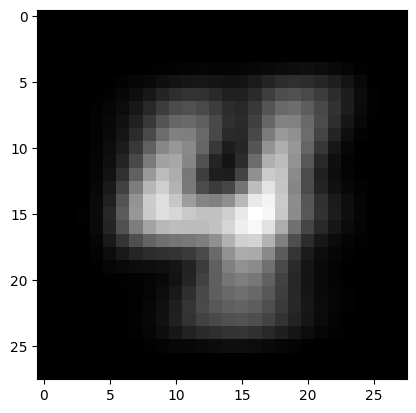

Class: 5


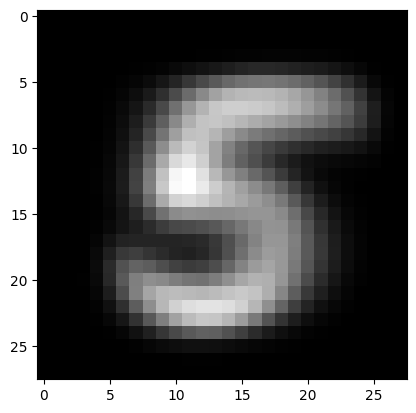

Class: 6


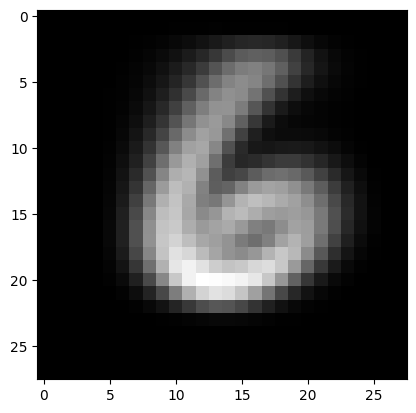

Class: 7


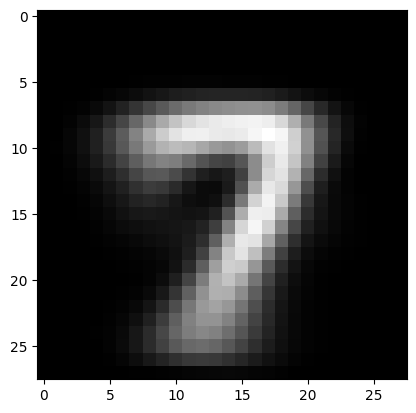

Class: 8


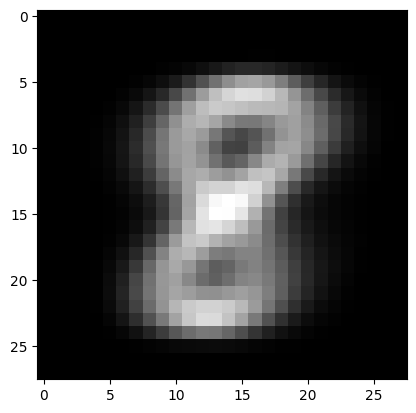

Class: 9


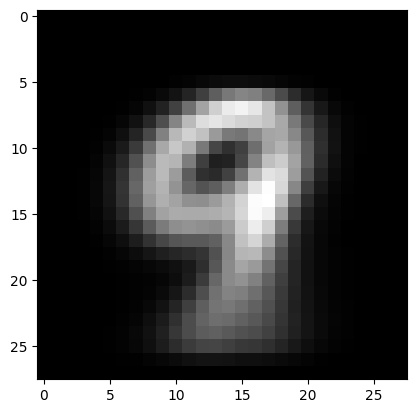

In [24]:
for i in range(10):
  plt.imshow(x_train_means[i].reshape(28,28),cmap='gray')
  print('Class:',i)
  plt.show()

In [25]:
start = time.time()
pred = knn(x_train_means, np.arange(10), x_test, 1)
elapsed_time = time.time() - start
print('Accuracy = {:.4f}'.format(accuracy_score(pred,y_test)))
print('Elapsed time = {:.4f} secs'.format(elapsed_time))

Accuracy = 0.8203
Elapsed time = 0.1295 secs


### Fashion-MNIST Class-Mean Prototypes

In [26]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train = np.float32(x_train/255).reshape(x_train.shape[0],-1)
x_test = np.float32(x_test/255).reshape(x_test.shape[0],-1)

In [27]:
x_train_means = find_means(x_train, y_train)

In [28]:
start = time.time()
pred = knn(x_train_means, np.arange(10), x_test, 1)
elapsed_time = time.time() - start
print('Accuracy = {:.4f}'.format(accuracy_score(pred,y_test)))
print('Elapsed time = {:.4f} secs'.format(elapsed_time))

Accuracy = 0.6768
Elapsed time = 0.1079 secs


## 8. Neighbor-Vote Confidence

The k-NN implementation is extended to return the number of neighbors that support the predicted class. Accuracy is then evaluated as a function of vote agreement.

In [29]:
def knn(x_train, y_train, x_test, k):
    d = distance(x_test,x_train)
    neighbors = np.argsort(d,axis=0)[:k]
    pred = most_common(y_train[neighbors])
    votes = np.sum(y_train[neighbors]==pred.reshape(1,-1),axis=0)
    return pred, votes

### MNIST Vote Agreement

In [30]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = np.float32(x_train/255).reshape(x_train.shape[0],-1)
x_test = np.float32(x_test/255).reshape(x_test.shape[0],-1)

In [31]:
k = 5
pred,votes = knn(x_train, y_train, x_test, k)
print('Overall accuracy = {:.4f}'.format(accuracy_score(pred,y_test)))

for i in range(1,k+1):
  i_votes = votes==i
  n = np.sum(i_votes)
  print(n,'classifications with',i,'votes')
  if n>0:
    print('Accuracy = {:.4f}'.format(accuracy_score(pred[votes==i],y_test[votes==i])))


Overall accuracy = 0.9688
0 classifications with 1 votes
81 classifications with 2 votes
Accuracy = 0.3457
321 classifications with 3 votes
Accuracy = 0.5981
555 classifications with 4 votes
Accuracy = 0.8721
9043 classifications with 5 votes
Accuracy = 0.9935


### Fashion-MNIST Vote Agreement

In [32]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train = np.float32(x_train/255).reshape(x_train.shape[0],-1)
x_test = np.float32(x_test/255).reshape(x_test.shape[0],-1)

In [33]:
k = 5
pred,votes = knn(x_train, y_train, x_test, k)
print('Overall accuracy = {:.4f}'.format(accuracy_score(pred,y_test)))

for i in range(1,k+1):
  i_votes = votes==i
  n = np.sum(i_votes)
  print(n,'classifications with',i,'votes')
  if n>0:
    print('Accuracy = {:.4f}'.format(accuracy_score(pred[votes==i],y_test[votes==i])))

Overall accuracy = 0.8554
2 classifications with 1 votes
Accuracy = 0.5000
385 classifications with 2 votes
Accuracy = 0.4286
1416 classifications with 3 votes
Accuracy = 0.5480
1498 classifications with 4 votes
Accuracy = 0.7530
6699 classifications with 5 votes
Accuracy = 0.9679


## 9. scikit-learn k-NN and Dataset Scale

The scikit-learn implementation is evaluated first on every tenth training/test observation and then on the full MNIST dataset. This makes the computational cost of instance-based prediction visible.

In [34]:
m = 10
n = 10
start = time.time()
model =  KNeighborsClassifier(algorithm='brute', n_jobs=-1)
start_train = time.time()
model.fit(x_train[::m], y_train[::m])
end_train = time.time()
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
start_test = time.time()
pred = model.predict(x_test[::n])
end_test = time.time()
print('Elapsed time testing= {:.4f} secs'.format(end_test-start_test))

print('Accuracy = {:.4f}'.format(accuracy_score(pred,y_test[::n])))
print('Confusion matrix')
print(confusion_matrix(y_test[::n], pred))

Elapsed time training= 0.0121 secs
Elapsed time testing= 0.3129 secs
Accuracy = 0.8200
Confusion matrix
[[ 89   0   1   3   0   0   5   0   0   0]
 [  1  95   0   3   1   0   1   0   0   0]
 [  1   0  76   2   7   0  12   0   0   0]
 [  6   0   2  73   6   0   1   0   0   0]
 [  0   0  16   3  67   0  11   0   0   0]
 [  0   0   0   0   0  77   4  20   0   4]
 [ 26   0  10   3   6   0  49   0   3   0]
 [  0   0   0   0   0   1   0  94   0   9]
 [  0   0   5   0   2   0   2   0  98   0]
 [  0   0   0   0   0   0   0   3   0 102]]


In [35]:
m = 1
n = 1
start = time.time()
model =  KNeighborsClassifier(algorithm='brute', n_jobs=-1)
start_train = time.time()
model.fit(x_train[::m], y_train[::m])
end_train = time.time()
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
start_test = time.time()
pred = model.predict(x_test[::n])
end_test = time.time()
print('Elapsed time testing= {:.4f} secs'.format(end_test-start_test))

print('Accuracy = {:.4f}'.format(accuracy_score(pred,y_test[::n])))
print('Confusion matrix')
print(confusion_matrix(y_test[::n], pred))

Elapsed time training= 0.0285 secs
Elapsed time testing= 31.9994 secs
Accuracy = 0.8554
Confusion matrix
[[855   1  17  16   3   1 100   1   6   0]
 [  8 968   4  12   4   0   3   0   1   0]
 [ 24   2 819  11  75   0  69   0   0   0]
 [ 41   8  15 860  39   0  34   0   3   0]
 [  2   1 126  26 773   0  71   0   1   0]
 [  1   0   0   0   0 822   5  96   1  75]
 [176   1 132  23  80   0 575   0  13   0]
 [  0   0   0   0   0   3   0 961   0  36]
 [  2   0  10   4   7   0  16   7 953   1]
 [  0   0   0   0   0   2   1  29   0 968]]


## 10. Selecting the Number of Neighbors

Odd values of \(k\) are evaluated using uniform voting. The saved results show how test accuracy changes as the neighborhood grows.

### Targeted Neighborhood-Size Comparison

Before the broader neighborhood sweep, three representative values are compared directly: \(k=1\), \(k=5\), and \(k=10\).

**Expected behavior:** increasing \(k\) may smooth local decisions but can also introduce more distant observations into the vote, potentially reducing accuracy when the neighborhood becomes too broad.

In [36]:
m = 1
n = 1
number_of_neighbors = [1, 5, 10]

for cur_num_neighbor in number_of_neighbors:
  start = time.time()
  model = KNeighborsClassifier(
      n_neighbors=cur_num_neighbor,
      algorithm='brute',
      n_jobs=-1
  )

  start_train = time.time()
  model.fit(x_train[::m], y_train[::m])
  end_train = time.time()

  print('Number of neighbors:', cur_num_neighbor)
  print('Elapsed time training = {:.4f} secs'.format(end_train-start_train))

  start_test = time.time()
  pred = model.predict(x_test[::n])
  end_test = time.time()

  print('Elapsed time testing = {:.4f} secs'.format(end_test-start_test))
  print('Accuracy = {:.4f}'.format(accuracy_score(pred, y_test[::n])))
  print('Confusion matrix')
  print(confusion_matrix(y_test[::n], pred))

Number of neighbors: 1
Elapsed time training = 0.0321 secs
Elapsed time testing = 26.1159 secs
Accuracy = 0.8497
Confusion matrix
[[800   2  20  26   5   0 142   1   4   0]
 [  7 975   2   8   4   0   3   0   1   0]
 [ 15   2 782  10  97   0  94   0   0   0]
 [ 35   9  14 850  42   0  48   0   2   0]
 [  5   2 127  34 734   0  97   0   1   0]
 [  0   0   0   0   0 863   2  68   1  66]
 [160   1 117  27  69   0 619   0   7   0]
 [  0   0   0   0   0   5   0 949   0  46]
 [  5   1   9   3   2   0  17   4 958   1]
 [  0   0   0   0   0   2   0  30   1 967]]
Number of neighbors: 5
Elapsed time training = 0.0375 secs
Elapsed time testing = 33.1598 secs
Accuracy = 0.8554
Confusion matrix
[[855   1  17  16   3   1 100   1   6   0]
 [  8 968   4  12   4   0   3   0   1   0]
 [ 24   2 819  11  75   0  69   0   0   0]
 [ 41   8  15 860  39   0  34   0   3   0]
 [  2   1 126  26 773   0  71   0   1   0]
 [  1   0   0   0   0 822   5  96   1  75]
 [176   1 132  23  80   0 575   0  13   0]
 [  0   

In [37]:
acc_list = []
k_list = np.arange(1,12,2)
train_time_list, test_time_list = [],[]

for k in k_list:
  print('k =',k)
  model =  KNeighborsClassifier(n_neighbors=k, algorithm='brute', n_jobs=-1)
  start_train = time.time()
  model.fit(x_train, y_train)
  end_train = time.time()
  print('Elapsed time training = {:.4f} secs'.format(end_train-start_train))
  train_time_list.append(end_train-start_train)
  start_test = time.time()
  pred = model.predict(x_test)
  end_test = time.time()
  print('Elapsed time testing = {:.4f} secs'.format(end_test-start_test))
  test_time_list.append(end_test-start_test)
  acc = accuracy_score(pred,y_test)
  print('Accuracy = {:.4f}'.format(acc))
  acc_list.append(acc)

k = 1
Elapsed time training = 0.0228 secs
Elapsed time testing = 26.4412 secs
Accuracy = 0.8497
k = 3
Elapsed time training = 0.0210 secs
Elapsed time testing = 26.4449 secs
Accuracy = 0.8541
k = 5
Elapsed time training = 0.0212 secs
Elapsed time testing = 27.5208 secs
Accuracy = 0.8554
k = 7
Elapsed time training = 0.0222 secs
Elapsed time testing = 26.3474 secs
Accuracy = 0.8540
k = 9
Elapsed time training = 0.0205 secs
Elapsed time testing = 26.3414 secs
Accuracy = 0.8519
k = 11
Elapsed time training = 0.0203 secs
Elapsed time testing = 25.5800 secs
Accuracy = 0.8495


## 11. Distance-Weighted k-NN

The same neighborhood search is repeated with inverse-distance weighting so closer neighbors contribute more strongly.

In [38]:
acc_list = []
k_list = np.arange(3,12,2)
train_time_list, test_time_list = [],[]

for k in k_list:
  print('k =',k)
  model =  KNeighborsClassifier(n_neighbors=k, weights='distance',algorithm='brute', n_jobs=-1)
  start_train = time.time()
  model.fit(x_train, y_train)
  end_train = time.time()
  print('Elapsed time training = {:.4f} secs'.format(end_train-start_train))
  train_time_list.append(end_train-start_train)
  start_test = time.time()
  pred = model.predict(x_test)
  end_test = time.time()
  print('Elapsed time testing = {:.4f} secs'.format(end_test-start_test))
  test_time_list.append(end_test-start_test)
  acc = accuracy_score(pred,y_test)
  print('Accuracy = {:.4f}'.format(acc))
  acc_list.append(acc)

k = 3
Elapsed time training = 0.0370 secs
Elapsed time testing = 25.1866 secs
Accuracy = 0.8561
k = 5
Elapsed time training = 0.0359 secs
Elapsed time testing = 25.9804 secs
Accuracy = 0.8577
k = 7
Elapsed time training = 0.0204 secs
Elapsed time testing = 26.2742 secs
Accuracy = 0.8541
k = 9
Elapsed time training = 0.0206 secs
Elapsed time testing = 26.2116 secs
Accuracy = 0.8530
k = 11
Elapsed time training = 0.0214 secs
Elapsed time testing = 26.6127 secs
Accuracy = 0.8508


Text(0, 0.5, 'testing time')

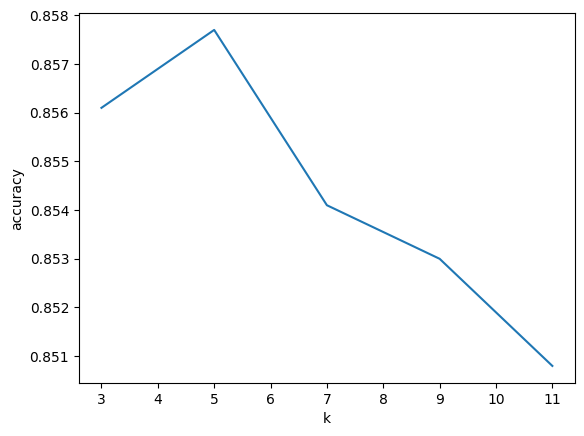

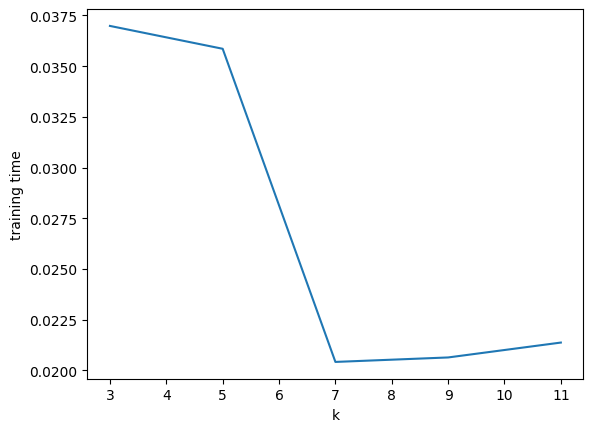

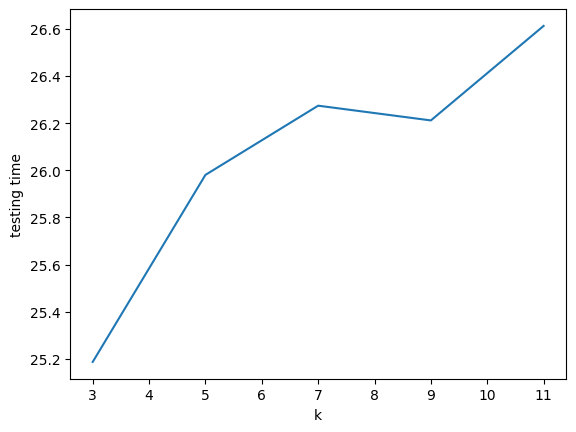

In [39]:
plt.figure()
plt.plot(k_list,acc_list)
plt.xlabel('k')
plt.ylabel('accuracy')

plt.figure()
plt.plot(k_list,train_time_list)
plt.xlabel('k')
plt.ylabel('training time')

plt.figure()
plt.plot(k_list,test_time_list)
plt.xlabel('k')
plt.ylabel('testing time')

## 12. Uniform vs. Distance Weighting

A direct comparison of the two weighting strategies is retained on a subsampled MNIST evaluation.

**Expected behavior:** distance weighting is expected to perform at least as well as uniform voting because closer neighbors receive greater influence in the class decision.

In [40]:

weight_values = ["uniform", "distance"]

for cur_weight_param in weight_values:
  m = 10
  n = 10
  start = time.time()
  model =  KNeighborsClassifier(weights=cur_weight_param, algorithm='brute', n_jobs=-1)
  start_train = time.time()
  model.fit(x_train[::m], y_train[::m])
  end_train = time.time()
  print("When distance: ", cur_weight_param)
  print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
  start_test = time.time()
  pred = model.predict(x_test[::n])
  end_test = time.time()
  print('Elapsed time testing= {:.4f} secs'.format(end_test-start_test))

  print('Accuracy = {:.4f}'.format(accuracy_score(pred,y_test[::n])))
  print('Confusion matrix')
  print(confusion_matrix(y_test[::n], pred))

When distance:  uniform
Elapsed time training= 0.0078 secs
Elapsed time testing= 0.2638 secs
Accuracy = 0.8200
Confusion matrix
[[ 89   0   1   3   0   0   5   0   0   0]
 [  1  95   0   3   1   0   1   0   0   0]
 [  1   0  76   2   7   0  12   0   0   0]
 [  6   0   2  73   6   0   1   0   0   0]
 [  0   0  16   3  67   0  11   0   0   0]
 [  0   0   0   0   0  77   4  20   0   4]
 [ 26   0  10   3   6   0  49   0   3   0]
 [  0   0   0   0   0   1   0  94   0   9]
 [  0   0   5   0   2   0   2   0  98   0]
 [  0   0   0   0   0   0   0   3   0 102]]
When distance:  distance
Elapsed time training= 0.0067 secs
Elapsed time testing= 0.2529 secs
Accuracy = 0.8100
Confusion matrix
[[ 88   0   1   3   0   0   6   0   0   0]
 [  1  95   0   3   1   0   1   0   0   0]
 [  1   0  69   1   9   0  18   0   0   0]
 [  5   0   1  73   7   0   2   0   0   0]
 [  0   0  13   3  68   0  13   0   0   0]
 [  0   0   0   0   0  73   5  21   0   6]
 [ 25   0   9   3   7   0  50   0   3   0]
 [  0   0  

## 13. Manhattan vs. Euclidean Distance

The Minkowski distance parameter \(p\) is varied between Manhattan distance (\(p=1\)) and Euclidean distance (\(p=2\)).

**Expected behavior:** Euclidean distance is expected to outperform Manhattan distance for this MNIST representation in the supplied comparison.

In [41]:
distance_norms = [1, 2]

for norm in distance_norms:
  m = 10
  n = 10
  start = time.time()
  model =  KNeighborsClassifier(p=norm, algorithm='brute', n_jobs=-1)
  start_train = time.time()
  model.fit(x_train[::m], y_train[::m])
  end_train = time.time()
  print('For distance norm p:  ', norm)
  print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
  start_test = time.time()
  pred = model.predict(x_test[::n])
  end_test = time.time()
  print('Elapsed time testing= {:.4f} secs'.format(end_test-start_test))

  print('Accuracy = {:.4f}'.format(accuracy_score(pred,y_test[::n])))
  print('Confusion matrix')
  print(confusion_matrix(y_test[::n], pred))

For distance norm p:   1
Elapsed time training= 0.0081 secs
Elapsed time testing= 6.5545 secs
Accuracy = 0.8410
Confusion matrix
[[ 88   0   2   3   0   0   5   0   0   0]
 [  2  95   0   2   2   0   0   0   0   0]
 [  2   0  74   3   8   0  11   0   0   0]
 [  3   0   2  76   7   0   0   0   0   0]
 [  0   0  16   4  70   0   7   0   0   0]
 [  0   0   0   0   0  90   0  13   1   1]
 [ 27   0   9   2   5   0  50   0   4   0]
 [  0   0   0   0   0   1   0  96   0   7]
 [  0   0   1   1   3   0   1   0 101   0]
 [  0   0   0   0   0   0   0   4   0 101]]
For distance norm p:   2
Elapsed time training= 0.0066 secs
Elapsed time testing= 0.2484 secs
Accuracy = 0.8200
Confusion matrix
[[ 89   0   1   3   0   0   5   0   0   0]
 [  1  95   0   3   1   0   1   0   0   0]
 [  1   0  76   2   7   0  12   0   0   0]
 [  6   0   2  73   6   0   1   0   0   0]
 [  0   0  16   3  67   0  11   0   0   0]
 [  0   0   0   0   0  77   4  20   0   4]
 [ 26   0  10   3   6   0  49   0   3   0]
 [  0   0 

## 14. Removing Constant Pixel Features

Pixels that remain constant across all training images do not help distinguish classes. The reduced feature matrix is evaluated with one-nearest-neighbor classification.

**Expected behavior:** removing pixels that do not vary across the training data should preserve classification accuracy while reducing unnecessary distance-computation work.

In [42]:

def get_unique_feature_columns(x_train):
  x_t = []
  # x_unique = []

  for i in range(x_train.shape[1]):
    sum = np.sum(x_train[:,i] - x_train[0,0])
    if sum != 0:
      x_t.append(i)

    # unique_values = np.unique(x_train[:,i])
    # if len(unique_values) > 1:
    #   x_unique.append(i)

  # print('equal ? ', np.sum(np.array(x_t) != np.array(x_unique)))

  return x_t


x_unique_features = get_unique_feature_columns(x_train)

x_train1 = x_train[:, x_unique_features]
x_test1 = x_test[:, x_unique_features]

# Train and evaluate the reduced-feature model
m = 1
n = 1
start = time.time()
model =  KNeighborsClassifier(n_neighbors=1, algorithm='brute', n_jobs=-1)
start_train = time.time()
model.fit(x_train1[::m], y_train[::m])
end_train = time.time()
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
start_test = time.time()
pred = model.predict(x_test1[::n])
end_test = time.time()
print('Elapsed time testing= {:.4f} secs'.format(end_test-start_test))

print('Accuracy = {:.4f}'.format(accuracy_score(pred,y_test[::n])))
print('Confusion matrix')
print(confusion_matrix(y_test[::n], pred))


Elapsed time training= 0.1209 secs
Elapsed time testing= 26.2285 secs
Accuracy = 0.8497
Confusion matrix
[[800   2  20  26   5   0 142   1   4   0]
 [  7 975   2   8   4   0   3   0   1   0]
 [ 15   2 782  10  97   0  94   0   0   0]
 [ 35   9  14 850  42   0  48   0   2   0]
 [  5   2 127  34 734   0  97   0   1   0]
 [  0   0   0   0   0 863   2  68   1  66]
 [160   1 117  27  69   0 619   0   7   0]
 [  0   0   0   0   0   5   0 949   0  46]
 [  5   1   9   3   2   0  17   4 958   1]
 [  0   0   0   0   0   2   0  30   1 967]]


## 15. Neighbor-Search Backends

Ball-tree, KD-tree, and brute-force search are compared on separate reduced MNIST train and test subsets. The original comparison logic is preserved, with the train/test subset construction corrected so test observations are not drawn from the training array.

In [43]:
(x_train_backend, y_train_backend), (x_test_backend, y_test_backend) = tf.keras.datasets.mnist.load_data()
x_train_backend = np.float32(x_train_backend / 255).reshape(x_train_backend.shape[0], -1)
x_test_backend = np.float32(x_test_backend / 255).reshape(x_test_backend.shape[0], -1)

# Use smaller, separate train and test subsets for the runtime comparison.
x_train_backend = x_train_backend[::5]
y_train_backend = y_train_backend[::5]
x_test_backend = x_test_backend[::5]
y_test_backend = y_test_backend[::5]

acc_list = []
k = 5
train_time_list, test_time_list = [], []

for alg in ['ball_tree', 'kd_tree', 'brute']:
    print('algorithm =', alg)
    model = KNeighborsClassifier(n_neighbors=k, algorithm=alg, n_jobs=-1)

    start_train = time.time()
    model.fit(x_train_backend, y_train_backend)
    end_train = time.time()
    print('Elapsed time training = {:.4f} secs'.format(end_train-start_train))
    train_time_list.append(end_train-start_train)

    start_test = time.time()
    pred = model.predict(x_test_backend)
    end_test = time.time()
    print('Elapsed time testing = {:.4f} secs'.format(end_test-start_test))
    test_time_list.append(end_test-start_test)

    acc = accuracy_score(pred, y_test_backend)
    print('Accuracy = {:.4f}'.format(acc))
    acc_list.append(acc)


algorithm = ball_tree
Elapsed time training = 0.7803 secs
Elapsed time testing = 17.3642 secs
Accuracy = 0.9530
algorithm = kd_tree
Elapsed time training = 1.0565 secs
Elapsed time testing = 25.8957 secs
Accuracy = 0.9530
algorithm = brute
Elapsed time training = 0.0180 secs
Elapsed time testing = 0.9564 secs
Accuracy = 0.9530


## 16. Comparative Results

| Experiment | Saved Accuracy |
|---|---:|
| Constant-zero baseline | 0.098 |
| Majority-class baseline | 0.114 |
| 1-NN from scratch, first 30 MNIST tests | 1.000 |
| Vectorized 3-NN, MNIST | **0.9705** |
| Vectorized 3-NN, Fashion-MNIST | 0.8541 |
| Mean-prototype 1-NN, MNIST | 0.8203 |
| Mean-prototype 1-NN, Fashion-MNIST | 0.6768 |
| scikit-learn default k-NN, full MNIST | 0.9688 |
| Uniform k-NN, best saved sweep result (k=3) | 0.9705 |
| Distance-weighted k-NN, best saved sweep result (k=3) | **0.9717** |
| Manhattan distance, saved comparison | 0.9618 |
| Euclidean distance, saved comparison | 0.9688 |
| Reduced constant-feature 1-NN | 0.9691 |

### Vote Agreement and Prediction Reliability

For MNIST with \(k=5\), the saved results show **99.35% accuracy** among predictions receiving all five agreeing neighbor votes, compared with much lower accuracy when only two or three neighbors support the predicted class. Fashion-MNIST shows the same pattern, demonstrating that neighbor agreement can provide a useful empirical confidence signal.

## 17. Key Findings

- The direct vectorized k-NN implementation reproduces strong MNIST performance but is computationally expensive because it explicitly constructs the distance matrix.
- Fashion-MNIST is substantially more difficult than MNIST for the same neighborhood rule.
- Replacing the complete training set with ten class-mean prototypes greatly reduces prediction time but also reduces accuracy.
- High neighbor-vote agreement is strongly associated with more reliable predictions in the saved experiments.
- Distance weighting slightly improves the best saved MNIST result.
- Euclidean distance outperforms Manhattan distance in the supplied comparison.
- Removing constant pixels preserves nearly the same predictive accuracy while reducing the feature representation.